# TrOCR experiments

Re-runnable report notebook for the TrOCR experiments. It contains the main saved results, training plots, and evaluation summaries. Full scripts are available in `src/fine_tuning/trocr/` and `src/zero_shot/`.

## Legend

- Zero-shot checkpoints: `microsoft/trocr-small-handwritten`, `microsoft/trocr-base-handwritten`, and `microsoft/trocr-large-handwritten`.
- Fine-tuning checkpoint: mainly `microsoft/trocr-large-handwritten`.
- Tested variants: full fine-tuning standard, full fine-tuning with dysgraphia oversampling, and soft fine-tuning.
- Note: `trocr-large-handwritten` was previously prepared on IAM, so IAM-200 is treated as a control subset rather than an independent generalization benchmark.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
TABLES = ROOT / 'results' / 'tables'
FIGURES = ROOT / 'results' / 'figures'


Loaded repository paths: results/tables and results/figures


## How to reuse this notebook

This notebook is both a saved experiment report and a runnable analysis notebook. A forked repository can be used in two ways:

- inspect the already saved outputs without running anything,
- rerun the cells after replacing files in `results/tables/` or `results/figures/`, or after producing new files with scripts from `src/`.

For new experiments, keep the original thesis outputs unchanged and save custom outputs under `results/custom_tables/` and `results/custom_figures/`.

In [2]:
RUN_TAG = 'custom'
CUSTOM_TABLES = ROOT / 'results' / 'custom_tables'
CUSTOM_FIGURES = ROOT / 'results' / 'custom_figures'
CUSTOM_TABLES.mkdir(parents=True, exist_ok=True)
CUSTOM_FIGURES.mkdir(parents=True, exist_ok=True)

def save_table(df, filename):
    """Save a custom result table under results/custom_tables/."""
    path = CUSTOM_TABLES / filename
    df.to_csv(path, index=False)
    print(f'Saved table: {path}')
    return path

def save_figure(fig, filename, dpi=200):
    """Save a custom matplotlib figure under results/custom_figures/."""
    path = CUSTOM_FIGURES / filename
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f'Saved figure: {path}')
    return path

print(f'Custom outputs will be saved to: {CUSTOM_TABLES} and {CUSTOM_FIGURES}')

Custom outputs will be saved to: results/custom_tables and results/custom_figures


## Zero-shot evaluation


In [2]:
pd.read_csv(TABLES / 'zero_shot_polish_test.csv').query("family == 'TrOCR'")


family,model,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
TrOCR,TrOCR-small-handwritten,241,0.7704,1.2200,0.3188,0.0366
TrOCR,TrOCR-base-handwritten,241,0.8464,1.4010,0.1894,0.0354
TrOCR,TrOCR-large-handwritten,241,0.5818,1.1370,0.4833,0.0499


In [3]:
pd.read_csv(TABLES / 'iam_200_summary_selected.csv').query("model == 'TrOCR-large'")


model,variant,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
TrOCR-large,base,200,0.0404,0.1046,0.9692,0.8979
TrOCR-large,soft FT,200,0.1346,0.3308,0.9098,0.6727
TrOCR-large,full FT standard,200,0.7798,0.9683,0.3782,0.0623


In [4]:
pd.read_csv(TABLES / 'malaysian_summary_selected.csv').query("model == 'TrOCR-large'")


model,variant,dataset,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
TrOCR-large,zero-shot,Malaysian raw,424,0.4512,1.0513,0.6021,0.0800
TrOCR-large,zero-shot,Malaysian inverted,424,0.1901,0.7646,0.8414,0.3569
TrOCR-large,full FT standard,Malaysian inverted,424,0.9087,1.1565,0.2052,0.0020
TrOCR-large,soft FT,Malaysian inverted,424,0.2883,0.7248,0.7593,0.2934


## Fine-tuning


In [5]:
pd.read_csv(TABLES / 'fine_tuning_polish_test.csv').query("model == 'TrOCR-large'")


model,variant,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
TrOCR-large,full FT standard,241,0.0156,0.0534,0.9884,0.9489
TrOCR-large,full FT oversampling,241,0.0147,0.0528,0.9900,0.9495
TrOCR-large,soft FT,241,0.0238,0.0871,0.9843,0.9153


Fine-tuning strongly improved the Polish test result, but full fine-tuning also narrowed the model toward the Polish form domain. This is visible in weaker transfer to IAM and Malaysian after fine-tuning.


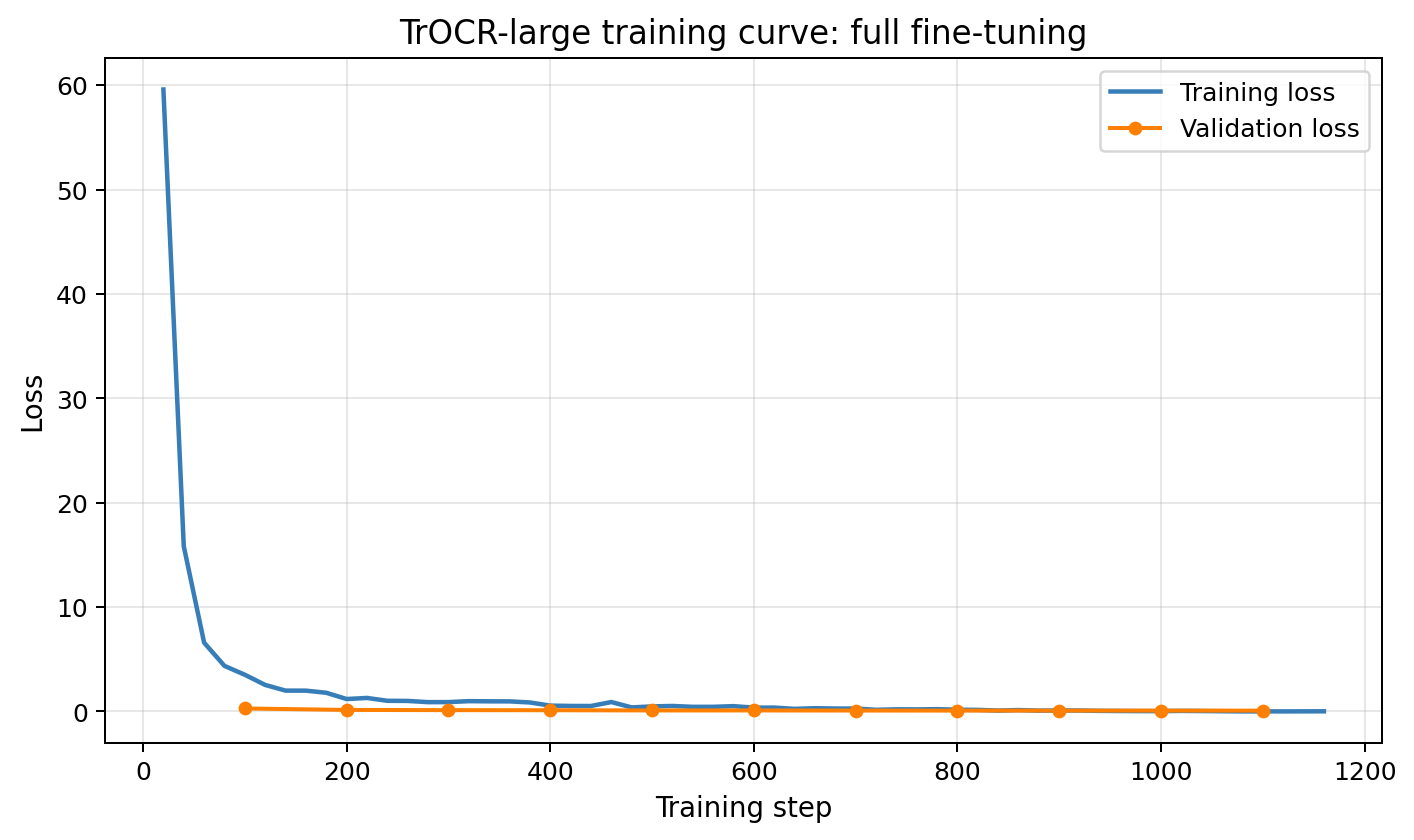

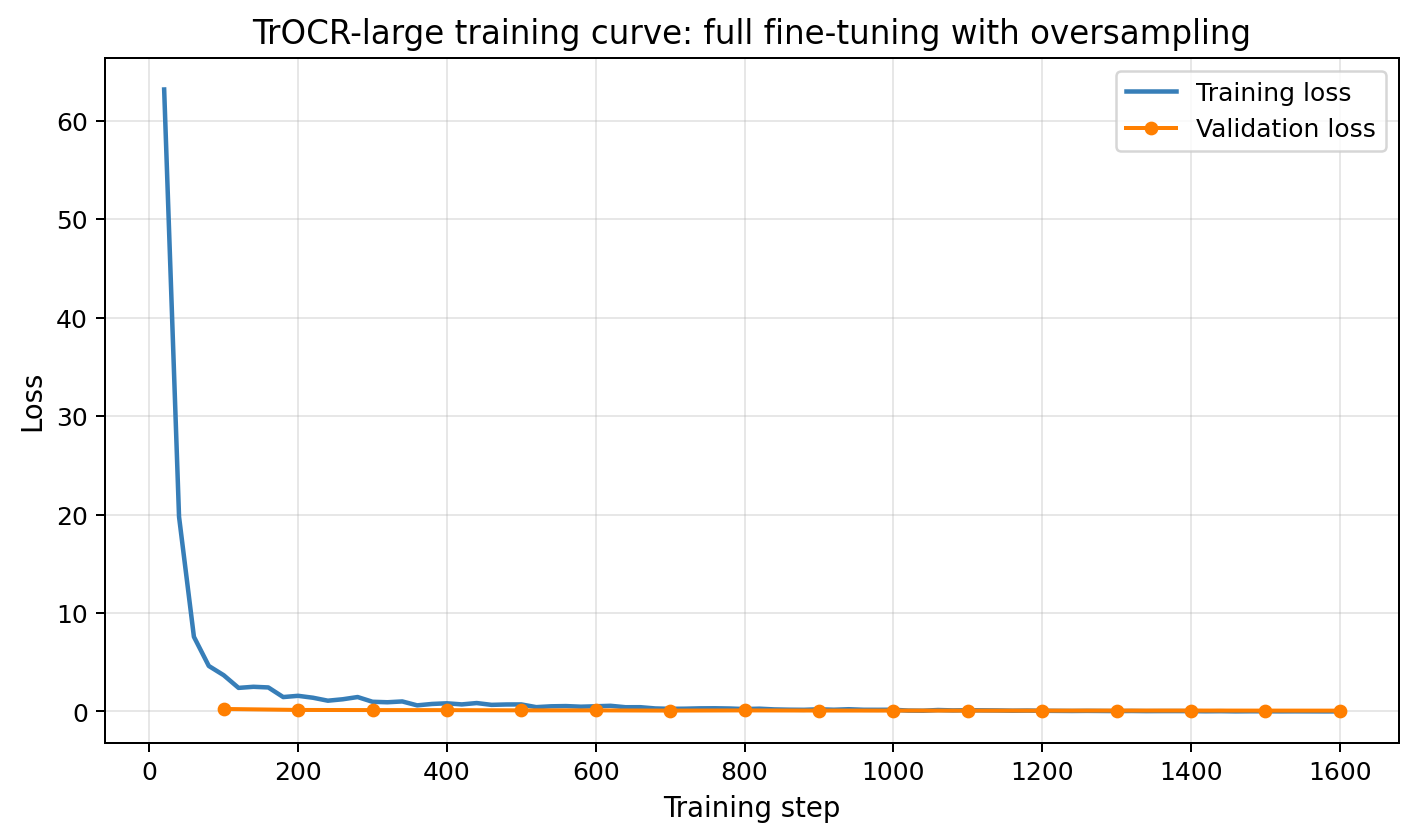

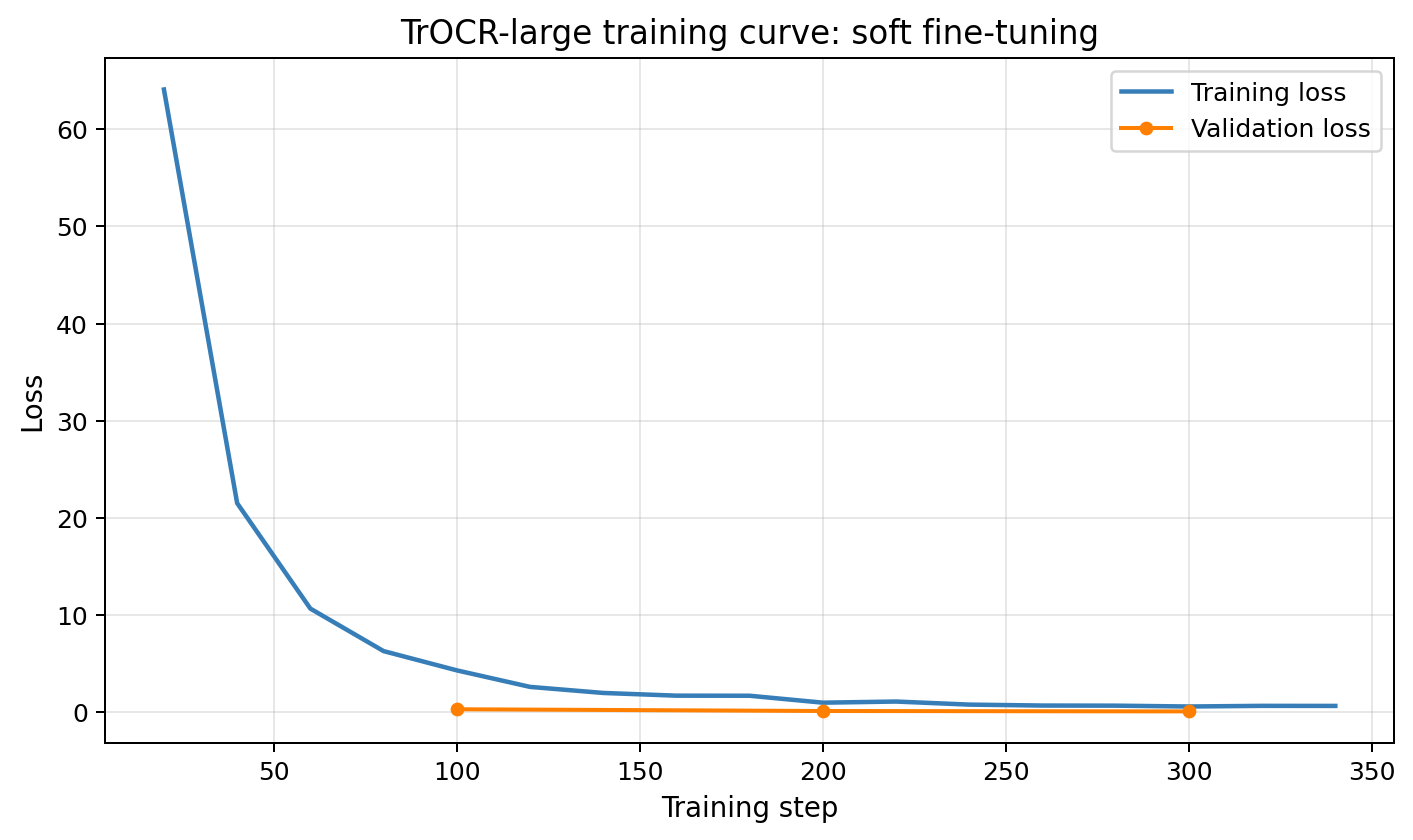

In [6]:
display(Image(filename=str(FIGURES / 'trocr_training_full_ft_standard.png')))
display(Image(filename=str(FIGURES / 'trocr_training_full_ft_oversampled.png')))
display(Image(filename=str(FIGURES / 'trocr_training_soft_ft_standard.png')))


## Resource usage


In [7]:
pd.read_csv(TABLES / 'resource_summary_selected.csv').query("model == 'TrOCR-large'")


model,variant,inference_seconds_mean,cuda_peak_allocated_mb_max,cuda_peak_reserved_mb_max,rss_after_mb_max
TrOCR-large,full FT oversampling,0.1493,1268.8000,2256.0000,NaN


## Character-level error analysis


In [8]:
pd.read_csv(TABLES / 'top_character_substitutions_best_models.csv').query("model == 'TrOCR-large'").head(12)


model,operation,reference_char,predicted_char,count
TrOCR-large,substitution,o,a,5.0000
TrOCR-large,substitution,p,P,4.0000
TrOCR-large,substitution,l,ł,3.0000
TrOCR-large,substitution,e,ę,3.0000
TrOCR-large,substitution,ą,a,2.0000
TrOCR-large,substitution,o,e,2.0000
TrOCR-large,substitution,n,c,2.0000
TrOCR-large,substitution,a,z,2.0000
TrOCR-large,substitution,a,c,2.0000
TrOCR-large,substitution,k,K,2.0000


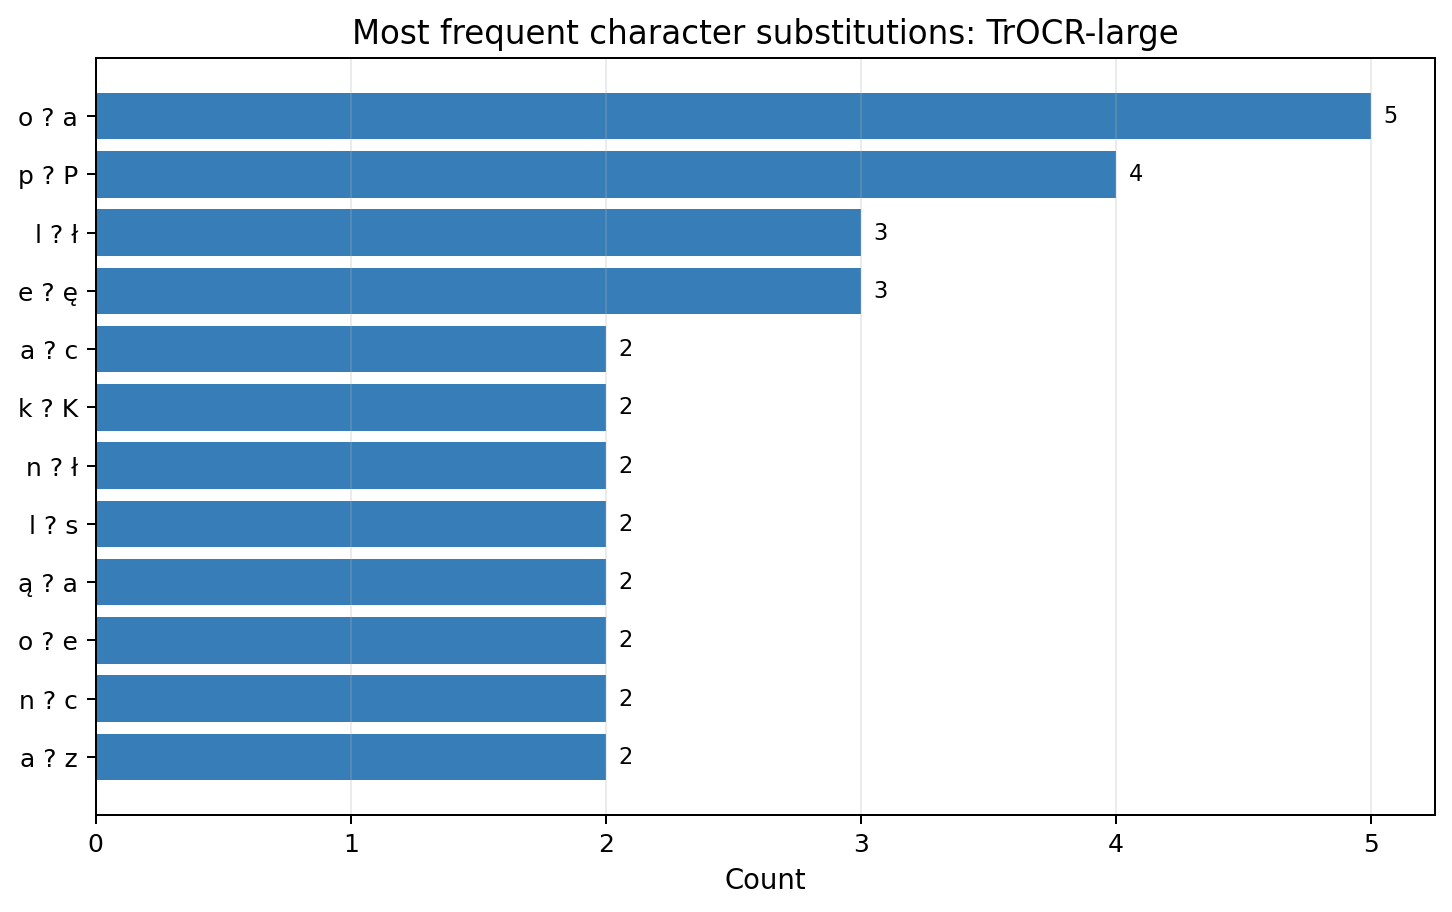

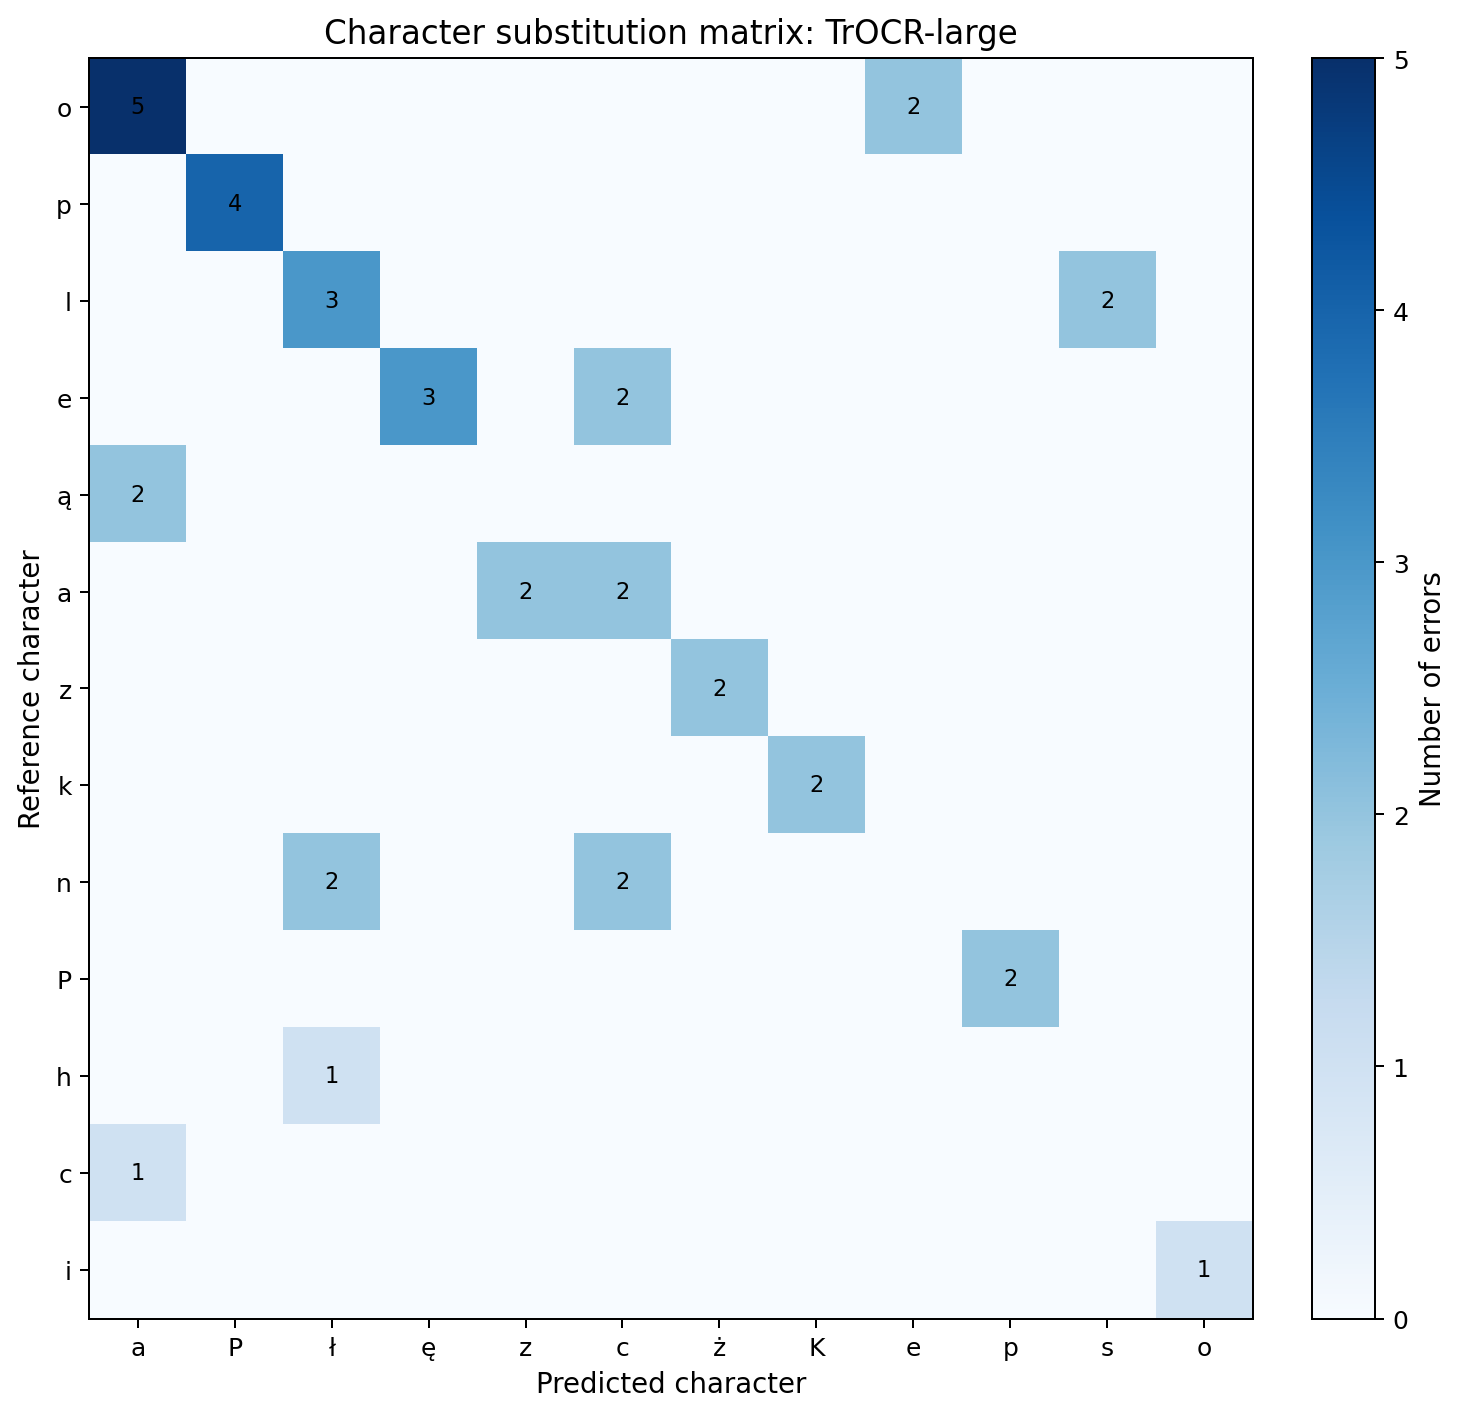

In [9]:
display(Image(filename=str(FIGURES / 'top_character_substitutions_trocr_large.png')))
display(Image(filename=str(FIGURES / 'character_substitution_heatmap_trocr_large.png')))
